In [28]:
import slangpy
from pathlib import Path
import matplotlib.pyplot as plt
import os 
cwd = Path(os.getcwd())

In [29]:
device = slangpy.create_device(slangpy.DeviceType.vulkan)
program = (cwd / "CSPrecompute.slang").as_posix()    

integrateGGX_E = device.create_compute_kernel(device.load_program(program, ["integrateGGX_E"]))    
integrateGGX_Eavg = device.create_compute_kernel(device.load_program(program, ["integrateGGX_Eavg"]))

ggx_E = device.create_buffer(element_count=32*32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_Eavg = device.create_buffer(element_count=32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)

integrateGGX_E.dispatch(thread_count=[1,1,1],vars={"output": ggx_E})
integrateGGX_Eavg.dispatch(thread_count=[1,1,1],vars={"output": ggx_Eavg})

[WARN] Slang compiler warnings:
/home/mos9527/Foundation/Scripts/../Editor/Shaders/IBRDF.slang(161): warning 41018: returning without initializing out parameter 'wt'
        return false;
        ^~~~~~
/home/mos9527/Foundation/Scripts/../Editor/Shaders/IBRDF.slang(161): warning 41018: returning without initializing out parameter 'etap'
        return false;
        ^~~~~~

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] Slang compiler warnings:
/home/mos9527/Foundation/Scripts/../Editor/Shaders/IBRDF.slang(161): warning 41018: returning without initializing out parameter 'wt'
        return false;
        ^~~~~~
/home/mos9527/Foundation/Scripts/../Editor/Shaders/IBRDF.slang(161): warning 41018: returning without initializing out parameter 'etap'
        return false;
        ^~~~~~



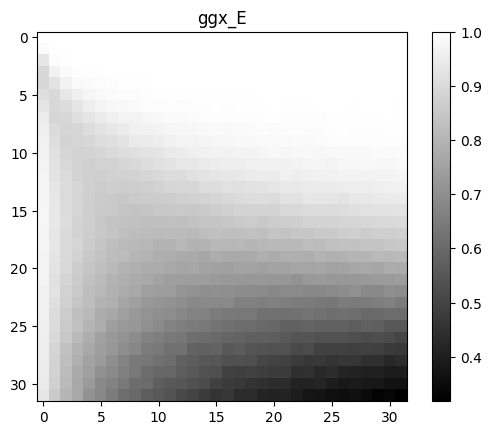

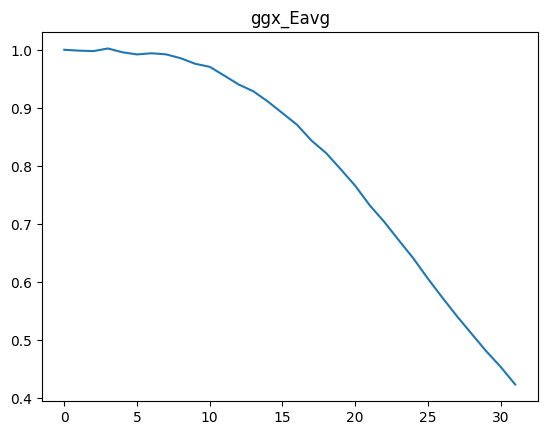

In [30]:
# E (1-E)
im_ggx_E = ggx_E.to_numpy().reshape((32,32))
plt.imshow(im_ggx_E, cmap='gray', interpolation='auto')
plt.title('ggx_E')
plt.colorbar()
plt.show()
# Eavg
im_ggx_Eavg = ggx_Eavg.to_numpy()
plt.plot(im_ggx_Eavg)
plt.title('ggx_Eavg')
plt.show()


In [31]:
# Dump it.
# We don't use image containers for this as this would be uploaded back to GPU anyway
print("// Generated by Scripts/CSPrecompute.ipynb")
print("constexpr float kGGXlutE[32 * 32] = {\n\t",end='')
for i, v in enumerate(ggx_E.to_numpy()):
    print(f"{v:.6f}f,", end=' ' if (i+1) % 32 else '\n\t')
print("\n};")

// Generated by Scripts/CSPrecompute.ipynb
constexpr float kGGXlutE[32 * 32] = {
	1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f,
	0.987980f, 0.998764f, 0.999523f, 0.999938f, 0.999973f, 0.999986f, 0.999752f, 0.999997f, 0.999997f, 0.999999f, 0.999999f, 0.999999f, 1.000000f, 1.000000f, 1.000000f, 0.999999f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f,
	0.932902f, 0.989414f, 0.997066f, 0.997679f, 0.999102f, 0.999515f, 0.999508f, 0.999806f, 0.999869f, 0.999940f, 0.999219f, 0.999720f, 0.999984f, 0.999987f, 0.999988f, 0.999748f, 0.999996f, 0.999753f, 0.999997f, 0.9

In [32]:
print("constexpr float kGGXlutEavg[32] = {\n\t",end='')
for v in ggx_Eavg.to_numpy():
    print(f"{v:.6f}f,", end=' ')
print("\n};")

constexpr float kGGXlutEavg[32] = {
	1.000354f, 0.998846f, 0.998015f, 1.002569f, 0.995992f, 0.992339f, 0.994305f, 0.992417f, 0.985790f, 0.976196f, 0.970947f, 0.955780f, 0.940393f, 0.928764f, 0.911097f, 0.891159f, 0.871125f, 0.843768f, 0.822342f, 0.794645f, 0.765992f, 0.732344f, 0.703719f, 0.671992f, 0.640816f, 0.605943f, 0.572986f, 0.541084f, 0.511060f, 0.481102f, 0.453938f, 0.423504f, 
};
